# Four aggregate return curves from `plot_iqm.py --compute-only`

Generate the four CSVs with `plot_iqm.py --compute-only`, then edit `PLOTS` in the setup cell to choose each CSV path, panel title, timesteps per task, and curve color. The list order maps to the 2 × 2 grid in reading order: (a), (b), (c), (d). Set `X_LABEL` and `Y_LABEL` there once for the whole figure. Each CSV should contain one panel; the notebook plots its saved center and uncertainty bounds directly without recomputing or smoothing them.

In [71]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Works when the kernel starts in either the repository root or scripts/.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts" / "plot_iqm.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "scripts" / "plot_iqm.py").exists():
    raise FileNotFoundError("Start the notebook in the repository root or scripts/.")

# (CSV path, panel title, timesteps per task, main curve color), in grid order.
PLOTS = [
    (PROJECT_ROOT / "output/plots/paper/dqn_cp_ji_data.csv", "DQN", 200_000, "#3A9AB2"),
    (PROJECT_ROOT / "output/plots/paper/sacd_cp_ji_data.csv", "SAC-D", 100_000, "#E85869"),
    (PROJECT_ROOT / "output/plots/paper/ddpg_ip_ji_data.csv", "DDPG", 100_000, "#7D69B4"),
    (PROJECT_ROOT / "output/plots/paper/sac_ip_ji_data.csv", "SAC", 100_000, "#60BFA6"),
]
X_LABEL = "Cumulative training timesteps"
Y_LABEL = "Mean episodic return (95% CI)"
OUT = PROJECT_ROOT / "output/plots/notebook"
OUTPUT_STEM = "aggregate_curves_2x2"
SAVE = True

# Optional overrides keyed by (grid position 0-3, line_index or method).
LINE_LABELS = {}  # Example: {(0, 0): "Raw", (0, 1): "EMA (span 5)"}
LINE_COLORS = {}  # Example: {(0, 0): "#3A9AB2", (0, 1): "#EBCC2A"}
PALETTE = ["#3A9AB2", "#E85869", "#7D69B4", "#60BFA6", "#EBCC2A"]

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.linewidth": 0.7,
    "grid.linewidth": 0.4,
    "lines.linewidth": 0.9,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [72]:
REQUIRED = {"label", "method", "test_env", "aggregation", "timestep", "center", "lower", "upper"}

def load_plot_data(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(
            f"{path}\nGenerate it with plot_iqm.py --compute-only or update PLOTS."
        )
    frame = pd.read_csv(path, dtype={"test_env": str})
    missing = REQUIRED.difference(frame.columns)
    if missing:
        raise ValueError(f"{path}: missing compute-only columns: {sorted(missing)}")
    if frame.empty:
        raise ValueError(f"No rows in {path}")
    for column in ("timestep", "center", "lower", "upper"):
        frame[column] = pd.to_numeric(frame[column], errors="raise")
    valid = np.isfinite(frame[["timestep", "center", "lower", "upper"]].to_numpy()).all(axis=1)
    if not valid.all():
        print(f"{path.name}: skipped {(~valid).sum()} rows with non-finite plotted values.")
        frame = frame.loc[valid].copy()
    if frame.empty:
        raise ValueError(f"No finite curve rows remain in {path}")
    if (frame["lower"] > frame["upper"]).any():
        raise ValueError(f"{path}: found lower bounds above upper bounds.")
    if "plot_index" in frame:
        if "line_index" not in frame:
            raise ValueError(f"{path}: plot_index requires line_index.")
        frame["plot_index"] = pd.to_numeric(frame["plot_index"], errors="raise").astype(int)
        frame["line_index"] = pd.to_numeric(frame["line_index"], errors="raise").astype(int)
    return frame

if len(PLOTS) != 4:
    raise ValueError("PLOTS must contain exactly four (path, title, task interval, color) entries.")

plot_data = []
for path, title, timesteps_per_task, plot_color in PLOTS:
    frame = load_plot_data(path)
    panel_column = "plot_index" if "plot_index" in frame else "test_env"
    if frame[panel_column].nunique(dropna=False) != 1:
        raise ValueError(f"{path} contains multiple panels; use one panel per CSV.")
    line_column = "line_index" if "plot_index" in frame else "method"
    plot_data.append((title, frame, line_column, timesteps_per_task, plot_color))
    print(f"{path.name}: {len(frame):,} rows, {frame[line_column].nunique()} lines, "
          f"{timesteps_per_task:,} timesteps/task")

dqn_cp_ji_data.csv: 3,840 rows, 1 lines, 200,000 timesteps/task
sacd_cp_ji_data.csv: 2,640 rows, 1 lines, 100,000 timesteps/task
ddpg_ip_ji_data.csv: 1,200 rows, 1 lines, 100,000 timesteps/task
sac_ip_ji_data.csv: 1,200 rows, 1 lines, 100,000 timesteps/task


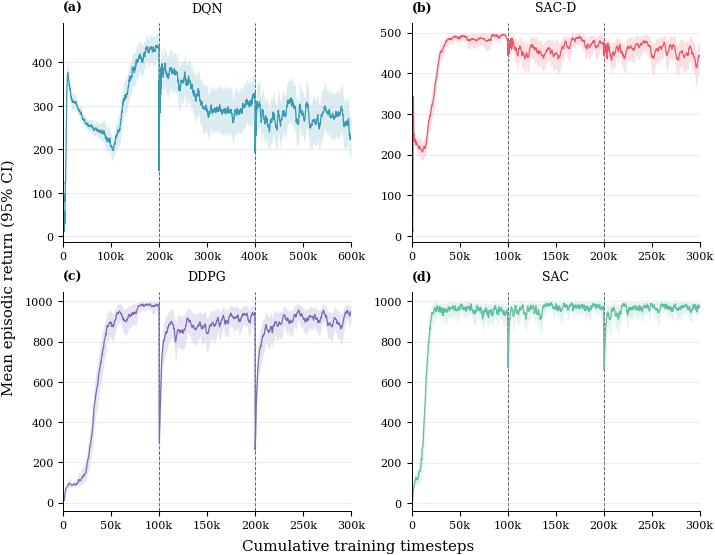

In [73]:
def format_timestep(value, _position):
    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:g}M"
    if abs(value) >= 1_000:
        return f"{value / 1_000:g}k"
    return f"{value:g}"

def plot_aggregate_curves(plot_data):
    fig, axes = plt.subplots(
        2, 2, figsize=(7.2, 5.6), squeeze=False, layout="constrained",
    )
    for grid_index, (ax, (title, panel, line_column, timesteps_per_task, plot_color)) in enumerate(
        zip(axes.flat, plot_data)
    ):
        if timesteps_per_task <= 0:
            raise ValueError(f"Grid position {grid_index + 1}: timesteps per task must be positive.")
        metrics = panel["aggregation"].dropna().unique()
        if len(metrics) != 1:
            raise ValueError(f"Grid position {grid_index + 1} must have one aggregation: {metrics}")
        ax.set_title(title, pad=8)
        ax.annotate(
            f"({chr(ord('a') + grid_index)})", xy=(0, 1), xytext=(0, 6),
            xycoords="axes fraction", textcoords="offset points",
            ha="left", va="bottom", fontweight="bold",
        )

        lines = list(panel.groupby(line_column, sort=False))
        labels = []
        for line_key, line in lines:
            override = LINE_LABELS.get((grid_index, line_key))
            label = override or str(line["label"].iloc[0]).strip()
            if not label or label.lower() == "nan":
                label = str(line["method"].iloc[0]).split("/")[-1].replace("_", " ")
            labels.append(label)
        duplicates = {label for label in labels if labels.count(label) > 1}

        for idx, ((line_key, line), label) in enumerate(zip(lines, labels)):
            line = line.sort_values("timestep")
            default_color = plot_color if idx == 0 else PALETTE[(grid_index + idx) % len(PALETTE)]
            color = LINE_COLORS.get((grid_index, line_key), default_color)
            display_label = f"{label} (line {idx + 1})" if label in duplicates else label
            x = line["timestep"].to_numpy(dtype=float)
            center = line["center"].to_numpy(dtype=float)
            lower = line["lower"].to_numpy(dtype=float)
            upper = line["upper"].to_numpy(dtype=float)
            ax.plot(x, center, color=color, label=display_label)
            ax.fill_between(x, lower, upper, color=color, alpha=0.18, linewidth=0)

        xmax = float(panel["timestep"].max())
        ax.set_xlim(0, xmax)
        boundary = timesteps_per_task
        while boundary < xmax:
            ax.axvline(boundary, color="0.4", linewidth=0.7, linestyle="--", zorder=0)
            boundary += timesteps_per_task
        ax.xaxis.set_major_formatter(FuncFormatter(format_timestep))
        ax.grid(axis="y", color="0.8", alpha=0.65)
        ax.spines[["top", "right"]].set_visible(False)
        if len(labels) > 1:
            ax.legend(frameon=False, loc="best")
    fig.supxlabel(X_LABEL)
    fig.supylabel(Y_LABEL)
    return fig

fig = plot_aggregate_curves(plot_data)
plt.show()

In [74]:
if SAVE:
    OUT.mkdir(parents=True, exist_ok=True)
    for suffix in ("pdf", "png"):
        path = OUT / f"{OUTPUT_STEM}.{suffix}"
        fig.savefig(path, dpi=300)
        print(f"Saved {path}")

Saved /home/seb/Code/uni/stability-gap-drl/output/plots/notebook/aggregate_curves_2x2.pdf
Saved /home/seb/Code/uni/stability-gap-drl/output/plots/notebook/aggregate_curves_2x2.png
